<a href="https://colab.research.google.com/github/ShefaliShettyy/All-Hyperparamter-Optimization/blob/master/call_center_simulations_priority_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Call Center Queue Simulation — Rule-Based Priority Engine

## What Changed
The original notebook used **hardcoded priority**:
```python
# OLD — never changes, ignores context
priority = {'vip': 0, 'escalation': 1, 'normal': 2}[customer_type]
```
This notebook replaces that with a **weighted rule engine**:
```python
# NEW — 6 rules × weights → dynamic priority score
ctx      = CallerContext(customer_type, skill, wait_so_far, ...)
priority = priority_engine.compute_priority(ctx)
```

## Architecture
```
CallerContext           ← all attributes of one caller
    │
PriorityEngine          ← 6 weighted rules → integer band 0..4
    │  Rule 1: customer_tier   (weight 4.0)
    │  Rule 2: skill_urgency   (weight 2.0)
    │  Rule 3: patience_aging  (weight 2.5)  ← anti-starvation
    │  Rule 4: repeat_caller   (weight 1.5)
    │  Rule 5: issue_severity  (weight 1.8)
    │  Rule 6: channel         (weight 0.8)
    │
SimulationConfig        ← all parameters (now includes severity + channel mix)
    │
    ├── run_simulation()       ← SimPy run
    │       ├── queue_monitor()
    │       ├── skill_arrival_stream() × 4 skills
    │       │       └── builds CallerContext, calls priority_engine
    │       └── handle_call()
    │
    ├── run_monte_carlo()      ← 30 replications → CI
    ├── print_results()
    ├── plot_results()
    ├── plot_queue_depth()
    └── find_optimal_staffing()
```

---
## Cell 1 — Install & Imports

In [1]:
!pip install simpy

In [2]:
import simpy
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy
from dataclasses import dataclass, field

print('All imports OK')

All imports OK


---
##  SimulationConfig



---
## SimulationConfig


In [3]:
@dataclass
class SimulationConfig:
    """
    Single source of truth for all simulation parameters.
    Change values here — nothing else needs editing.
    """

    # ── Staffing ───────────────────────────────────────────────────────────────
    agents_per_skill: dict = field(default_factory=lambda: {
        'billing':   2,
        'technical': 2,
        'account':   1,
        'general':   2,
    })

    # ── Arrival rates (minutes between calls per skill) ────────────────────────
    iat_by_skill: dict = field(default_factory=lambda: {
        'billing':   3.0,
        'technical': 4.0,
        'account':   4.0,
        'general':   2.0,
    })

    # ── Service & patience ─────────────────────────────────────────────────────
    mean_service_minutes:  float = 5.0
    patience_mean_minutes: float = 10.0

    # ── Simulation timing ──────────────────────────────────────────────────────
    simulation_time: int = 480
    warmup_minutes:  int = 30
    replications:    int = 30

    # ── Business KPIs ──────────────────────────────────────────────────────────
    sla_target_minutes:  float = 3.0
    cost_per_agent_hour: float = 25.0

    # ── Customer type mix ──────────────────────────────────────────────────────
    # These are sampled to build a CallerContext for each arriving call.
    customer_types: list = field(default_factory=lambda: ['vip', 'escalation', 'normal'])
    customer_probs: list = field(default_factory=lambda: [0.05, 0.10, 0.85])

    # ── Issue severity mix (NEW — feeds Rule 5) ────────────────────────────────
    severity_types: list = field(default_factory=lambda: ['emergency', 'high', 'normal', 'low'])
    severity_probs: list = field(default_factory=lambda: [0.03, 0.12, 0.75, 0.10])
    # Real mix: 3% emergencies, 12% high-severity, 75% normal, 10% low-priority

    # ── Channel mix (NEW — feeds Rule 6) ──────────────────────────────────────
    channel_types: list = field(default_factory=lambda: ['phone', 'callback', 'chat'])
    channel_probs: list = field(default_factory=lambda: [0.70, 0.20, 0.10])

    # ── Repeat caller probability (NEW — feeds Rule 4) ────────────────────────
    repeat_caller_prob: float = 0.15   # 15% of callers are calling back today

    # ── Derived properties ─────────────────────────────────────────────────────
    @property
    def total_agent_seats(self) -> int:
        return sum(self.agents_per_skill.values())

    @property
    def hourly_cost(self) -> float:
        return self.total_agent_seats * self.cost_per_agent_hour

    def traffic_intensity(self, skill: str) -> float:
        lam = 1.0 / self.iat_by_skill[skill]
        n   = self.agents_per_skill[skill]
        return (lam * self.mean_service_minutes) / n

    def print_load_summary(self):
        print('\n── Traffic Intensity Check ──────────────────────────')
        print(f"  {'Skill':<12}  {'IAT':>6}  {'Agents':>7}  {'ρ':>6}  Status")
        print('  ' + '-'*52)
        for skill in self.iat_by_skill:
            rho    = self.traffic_intensity(skill)
            n      = self.agents_per_skill[skill]
            iat    = self.iat_by_skill[skill]
            status = ('UNDERLOADED ' if rho < 0.5
                      else 'OVERLOADED ' if rho > 0.95
                      else 'OK')
            print(f'  {skill:<12}  {iat:>5.1f}m  {n:>7}  {rho:>6.2f}  {status}')
        print(f'\n  Total agent seats : {self.total_agent_seats}')
        print(f'  Hourly cost       : ${self.hourly_cost:.0f}')
        print('─────────────────────────────────────────────────────\n')


---
## Message Processors

In [4]:
class MessageProcessor:
    """Base class — subclass to redirect event log."""
    def process(self, message: str): raise NotImplementedError
    def stop(self): pass

class ConsoleMessageProcessor(MessageProcessor):
    """Prints every event. Use for debugging a single run."""
    def process(self, message: str): print(message)

class SilentMessageProcessor(MessageProcessor):
    """Suppresses all output. Use during Monte Carlo."""
    def process(self, message: str): pass

class FileMessageProcessor(MessageProcessor):
    """Writes events to a file."""
    def __init__(self, path: str):
        self._f = open(path, 'w')
    def process(self, message: str):
        self._f.write(message + '\n')
    def stop(self):
        self._f.close()

---
##  Metrics Collector



In [5]:
class Metrics:
    def __init__(self, config: SimulationConfig):     #record/store what happens during the simulation
        self.config           = config
        self.total_customers  = 0
        self.served_customers = 0
        self.abandoned_calls  = 0

        # (sim_time, wait_minutes) — warmup discarded at analysis time
        self.wait_records: list = []

        self.max_wait = 0.0
        self.min_wait = float('inf')

        self.effective_times: dict = {}   # resource → total busy minutes
        self.calls_per_skill: dict = {s: 0 for s in config.iat_by_skill}
        self.wait_by_skill:   dict = {s: [] for s in config.iat_by_skill}

        self.agents: dict = {}  # filled by run_simulation

        # NEW: queue depth sampled every minute
        # {skill: [(minute, depth), ...]}
        self.queue_depth_history: dict = {s: [] for s in config.iat_by_skill}

    # ── Registration ──────────────────────────────────────────────────────────

    def register_arrival(self):  #when new caller comes increase the count
        self.total_customers += 1

    def register_served(self, skill: str, wait: float, sim_time: float, resource): #when the caller gets CONNECTED to the agent
        self.served_customers += 1                                               #one more customer is served
        self.wait_records.append((sim_time, wait))                                 #store when the customer was served and waiting time
        self.wait_by_skill[skill].append(wait)                                     #store waiting time by skill
        self.max_wait = max(self.max_wait, wait)                                   #update max waiting time
        self.min_wait = min(self.min_wait, wait)                                   #update min waiting time

    def register_service_time(self, resource, duration: float): #track how long the agent is busy
        self.effective_times[resource] = (
            self.effective_times.get(resource, 0.0) + duration
        )

    def register_abandoned(self):
        self.abandoned_calls += 1

    # ── Statistics ────────────────────────────────────────────────────────────

    def _steady_waits(self):                                      #remove warm up period data
        warmup = self.config.warmup_minutes
        return [w for t, w in self.wait_records if t >= warmup]

    def average_wait(self) -> float:
        waits = self._steady_waits()
        return float(np.mean(waits)) if waits else 0.0

    def sla_compliance(self) -> float:                            #percentage of the call answered within sla targets
        waits = self._steady_waits()
        if not waits:
            return 0.0
        target = self.config.sla_target_minutes
        return 100.0 * sum(1 for w in waits if w <= target) / len(waits)

    def utilization(self) -> float:
        """True utilization = total busy / (seats × sim_time)."""
        total_busy = sum(self.effective_times.values())
        capacity   = self.config.total_agent_seats * self.config.simulation_time
        return (total_busy / capacity * 100.0) if capacity > 0 else 0.0

    def abandon_rate(self) -> float:
        if self.total_customers == 0:
            return 0.0
        return 100.0 * self.abandoned_calls / self.total_customers

---
##  Random Variate Generators

In [6]:
def gen_interarrival(mean_iat: float, rng) -> float:
    return rng.exponential(mean_iat)

def gen_service_time(mean_minutes: float, rng) -> float:
    return rng.exponential(mean_minutes)

def gen_patience(mean_minutes: float, rng) -> float:
    return rng.exponential(mean_minutes)

---
## Rule-Based Priority Engine


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# RULE-BASED WEIGHTED PRIORITY ENGINE
# Replaces the old hardcoded:  priority = {'vip': 0, 'escalation': 1, 'normal': 2}[customer_type]
# ═══════════════════════════════════════════════════════════════════════════════
#
# WHY THE OLD WAY IS WRONG
# ─────────────────────────
#  Old code assigned a FIXED number to each customer type, once, forever.
#  It never considered: how long someone waited, what skill they need,
#  whether they called before, or how severe their issue is.
#
# THE NEW APPROACH: Weighted Rule Voting
# ───────────────────────────────────────
#  Each rule is a "voter" that evaluates the caller's situation and casts
#  a vote (0.0 = not urgent → 1.0 = very urgent).
#  The vote is multiplied by the rule's weight (importance).
#  Total weighted score → mapped to a SimPy priority band (0=first served).
#
# RULES USED (grounded in real call-center standards)
# ─────────────────────────────────────────────────────
#  1. CUSTOMER TIER     (weight 4.0) — VIP/escalation contractual SLAs
#  2. SKILL URGENCY     (weight 2.0) — technical outages > billing queries
#  3. PATIENCE AGING    (weight 2.5) — boost callers nearing abandonment
#  4. REPEAT CALLER     (weight 1.5) — 2nd call = FCR failure, prioritize fix
#  5. ISSUE SEVERITY    (weight 1.8) — emergency regardless of tier
#  6. CHANNEL           (weight 0.8) — scheduled callbacks expect punctuality

from dataclasses import dataclass, field
from typing import List, Callable, Optional

@dataclass
class CallerContext:
    """Everything known about a caller. Passed to every rule."""
    customer_type:  str          # 'vip', 'escalation', 'normal'
    skill:          str          # 'billing', 'technical', 'account', 'general'
    arrival_time:   float        # sim minutes at arrival
    wait_so_far:    float = 0.0  # minutes already spent in queue (for aging rule)
    call_number:    int   = 1    # how many times this caller phoned today
    channel:        str   = 'phone'    # 'phone', 'callback', 'chat'
    issue_severity: str   = 'normal'   # 'emergency', 'high', 'normal', 'low'


@dataclass
class PriorityRule:
    """A single rule: name, weight, and a function CallerContext → float[0,1]."""
    name:        str
    weight:      float   #how i,portant the rule is
    evaluate:    Callable   # Return score (CallerContext) -> float in [0.0, 1.0]
    description: str = ""


class PriorityEngine:
    """
    Computes SimPy queue priority from weighted rules.

    SCORE FORMULA:
        raw_score = Σ  rule.weight × rule.evaluate(caller_context)

    PRIORITY BANDS (SimPy serves lower numbers first):
        score ≥ 7.0  →  band 0  CRITICAL
        score ≥ 5.0  →  band 1  HIGH
        score ≥ 3.0  →  band 2  ELEVATED
        score ≥ 1.5  →  band 3  STANDARD
        else         →  band 4  LOW
    """

    BAND_LABELS = {0: 'CRITICAL', 1: 'HIGH', 2: 'ELEVATED', 3: 'STANDARD', 4: 'LOW'}

    THRESHOLDS = [
        (7.0, 0),   # CRITICAL           #if score is less the 70 band 1
        (5.0, 1),   # HIGH               #if score is less then 50 band 2
        (3.0, 2),   # ELEVATED
        (1.5, 3),   # STANDARD
        (0.0, 4),   # LOW
    ]

    def __init__(self, rules: Optional[List[PriorityRule]] = None):
        self.rules = rules if rules is not None else self._default_rules()

    @staticmethod
    def _default_rules() -> List[PriorityRule]:
        """
        6 real call-center rules. Each returns a signal in [0, 1].
        Modify weights here to change relative importance without touching simulation code.
        """
        return [

            # RULE 1 — CUSTOMER TIER
            # VIPs have signed SLA contracts (e.g. answer in 60s).
            # Escalations are already frustrated — further delay kills CSAT.
            # Source: ICMI Best Practices, Zendesk CX Benchmarks.
            PriorityRule(
                name="customer_tier",
                weight=4.0,
                description="VIP/escalation contractual SLA",
                evaluate=lambda ctx: {
                    'vip':        1.0,
                    'escalation': 0.65,
                    'normal':     0.0,
                }.get(ctx.customer_type, 0.0)
            ),

            # RULE 2 — SKILL URGENCY
            # Technical outages affect multiple downstream users.
            # Account issues have security/fraud implications.
            # Billing is important but rarely time-critical.
            # Source: COPC CX Standard, HDI Support Center Practices.
            PriorityRule(
                name="skill_urgency",
                weight=2.0,
                description="Time-criticality of the skill type",
                evaluate=lambda ctx: {
                    'technical': 0.9,
                    'account':   0.75,
                    'billing':   0.5,
                    'general':   0.2,
                }.get(ctx.skill, 0.3)
            ),

            # RULE 3 — PATIENCE AGING (Queue Anti-Starvation)
            # As a normal caller approaches their patience limit, their
            # priority grows — preventing VIPs from starving normal callers.
            # Source: Erlang-C theory, Genesys/Avaya routing docs.
            PriorityRule(
                name="patience_aging",
                weight=2.5,
                description="Priority grows as caller nears abandonment",
                evaluate=lambda ctx: min(ctx.wait_so_far / 8.0, 1.0)
                # Linearly ramps to 1.0 after 8 min waiting
            ),

            # RULE 4 — REPEAT CALLER
            # 2nd call = First Call Resolution failure.
            # FCR is a primary call-center KPI (target: >80%).
            # Repeat callers should be fast-tracked to avoid further damage.
            # Source: CallMiner 2023, NICE inContact benchmarks.
            PriorityRule(
                name="repeat_caller",
                weight=1.5,
                description="Repeat callers signal unresolved issues",
                evaluate=lambda ctx: min((ctx.call_number - 1) * 0.4, 1.0)
                # 1st call=0.0, 2nd=0.4, 3rd=0.8, 4+capped at 1.0
            ),

            # RULE 5 — ISSUE SEVERITY
            # The nature of the problem matters independently of tier.
            # An emergency from a normal customer outranks a routine VIP call.
            # Source: ITIL v4 incident classification, HDI severity matrix.
            PriorityRule(
                name="issue_severity",
                weight=1.8,
                description="Issue severity independent of customer tier",
                evaluate=lambda ctx: {
                    'emergency': 1.0,
                    'high':      0.6,
                    'normal':    0.2,
                    'low':       0.0,
                }.get(ctx.issue_severity, 0.2)
            ),

            # RULE 6 — CHANNEL
            # Callback customers scheduled a timeslot — punctuality expected.
            # Phone callers have open-ended tolerance.
            # Source: Aspect Workforce, Five9 callback routing documentation.
            PriorityRule(
                name="channel",
                weight=0.8,
                description="Scheduled channels expect punctual service",
                evaluate=lambda ctx: {
                    'callback': 0.7,
                    'phone':    0.3,
                    'chat':     0.1,
                }.get(ctx.channel, 0.3)
            ),
        ]

    def compute_score(self, ctx: CallerContext) -> float:                         #explain final urgent score for a caller
        """Raw weighted urgency score. Higher = more urgent."""
        return sum(rule.weight * rule.evaluate(ctx) for rule in self.rules)

    def compute_priority(self, ctx: CallerContext) -> int:                        #converts score -> actual queue priority #retun int 1 2 3 4
        """Returns SimPy integer priority. Lower = served first."""               #smaller number more urgent 1->first, 2->second etc  lower number = higher priority
        score = self.compute_score(ctx)
        for threshold, band in self.THRESHOLDS:
            if score >= threshold:
                return band
        return 4  # LOW

    def explain(self, ctx: CallerContext) -> str:
        """Prints a human-readable rule breakdown for a given caller."""
        lines = [f"Priority breakdown — {ctx.customer_type} | {ctx.skill} | wait={ctx.wait_so_far:.1f}m"]
        total = 0.0
        for rule in self.rules:
            signal = rule.evaluate(ctx)
            contrib = rule.weight * signal
            total += contrib
            lines.append(
                f"  {rule.name:<20}  wt={rule.weight:.1f}  sig={signal:.2f}  "
                f"contrib={contrib:.2f}   [{rule.description}]"
            )
        priority = self.compute_priority(ctx)
        lines.append(f"  {'─'*70}")
        lines.append(f"  Total score: {total:.2f}  →  Band {priority}: {self.BAND_LABELS[priority]}")
        return '\n'.join(lines)


# ── Instantiate the global engine ────────────────────────────────────────────
priority_engine = PriorityEngine()
print("Rule-based PriorityEngine ready.")
print(f"  Rules loaded: {[r.name for r in priority_engine.rules]}")


Rule-based PriorityEngine ready.
  Rules loaded: ['customer_tier', 'skill_urgency', 'patience_aging', 'repeat_caller', 'issue_severity', 'channel']


### Priority Explainer
See how scores are computed for example callers:

In [8]:
# ── Sanity-check: show how priority is computed for different caller profiles ──
test_cases = [
    CallerContext(customer_type='vip',        skill='technical', arrival_time=120,
                  wait_so_far=0.0, call_number=1, issue_severity='normal'),
    CallerContext(customer_type='normal',      skill='technical', arrival_time=120,
                  wait_so_far=7.5, call_number=1, issue_severity='emergency'),
    CallerContext(customer_type='escalation',  skill='account',   arrival_time=120,
                  wait_so_far=2.0, call_number=2, issue_severity='high'),
    CallerContext(customer_type='normal',      skill='general',   arrival_time=120,
                  wait_so_far=0.0, call_number=1, issue_severity='normal'),
    CallerContext(customer_type='normal',      skill='billing',   arrival_time=120,
                  wait_so_far=0.0, call_number=3, issue_severity='normal',
                  channel='callback'),
]

for ctx in test_cases:
    print(priority_engine.explain(ctx))
    print()


Priority breakdown — vip | technical | wait=0.0m
  customer_tier         wt=4.0  sig=1.00  contrib=4.00   [VIP/escalation contractual SLA]
  skill_urgency         wt=2.0  sig=0.90  contrib=1.80   [Time-criticality of the skill type]
  patience_aging        wt=2.5  sig=0.00  contrib=0.00   [Priority grows as caller nears abandonment]
  repeat_caller         wt=1.5  sig=0.00  contrib=0.00   [Repeat callers signal unresolved issues]
  issue_severity        wt=1.8  sig=0.20  contrib=0.36   [Issue severity independent of customer tier]
  channel               wt=0.8  sig=0.30  contrib=0.24   [Scheduled channels expect punctual service]
  ──────────────────────────────────────────────────────────────────────
  Total score: 6.40  →  Band 1: HIGH

Priority breakdown — normal | technical | wait=7.5m
  customer_tier         wt=4.0  sig=0.00  contrib=0.00   [VIP/escalation contractual SLA]
  skill_urgency         wt=2.0  sig=0.90  contrib=1.80   [Time-criticality of the skill type]
  patience_agi

---
## Core SimPy Processes


In [9]:
def queue_monitor(env, agents, metrics): #watches queue
    """Check every min how many people are waiting."""
    while True:
        yield env.timeout(1)                                                   #wait every one min
        for skill, resource in agents.items():
            depth = len(resource.queue)
            metrics.queue_depth_history[skill].append((env.now, depth))       #store time and queue size eg: time 10-> 3 people are waiting


def handle_call(env, caller_name, agent_resource, skill,
                call_duration, priority, metrics, mp, config, rng):  #process one call at a time
    """
    SimPy process for one caller.
    Priority is now a dynamic integer from PriorityEngine, not a hardcoded map.
    """
    arrival_time = env.now                                                     #caller arrieves
    patience     = gen_patience(config.patience_mean_minutes, rng)             #generates patience , for how long will they wait

    mp.process(
        f"{caller_name} arrives | skill={skill} | priority={priority}"         #printing and logging
        f" | queue={len(agent_resource.queue)}"
        f" | busy={agent_resource.count}/{agent_resource.capacity}"
    )

    request = agent_resource.request(priority=priority)                        #get a agent
    result  = yield request | env.timeout(patience)                             #wait for agent or patience runs out

    if request not in result:                                                   #check if customer is abundent and store the count
        request.cancel()
        metrics.register_abandoned()
        mp.process(f"{caller_name} ABANDONED after {patience:.2f} min")
        return

    wait_time = env.now - arrival_time                                          #customer gets agent so calculate wait time
    metrics.register_served(skill, wait_time, env.now, agent_resource)          #record waitng time,skill, time
    mp.process(
        f"{caller_name} CONNECTED at t={env.now:.1f} | waited {wait_time:.2f} min"
    )

    yield env.timeout(call_duration)                                            #wait for call suration time
    metrics.register_service_time(agent_resource, call_duration)
    agent_resource.release(request)                                             #agent is free
    mp.process(f"{caller_name} DONE at t={env.now:.1f}")


def skill_arrival_stream(env, skill, config, agents, metrics, mp, rng):      #Call generator
    """
    One independent Poisson arrival stream per skill type.

    KEY CHANGE FROM ORIGINAL
    ─────────────────────────
    OLD:  priority = {'vip': 0, 'escalation': 1, 'normal': 2}[customer_type]
          → Hardcoded lookup. VIP always 0, normal always 2. Never changes.

    NEW:  Build a CallerContext with all caller attributes.
          Pass to PriorityEngine.compute_priority() which runs 6 weighted rules.
          Priority emerges from the combination of rules — not from a fixed table.

    This means:
    - A 'normal' caller waiting 9 minutes can jump ahead of a fresh VIP
      (patience_aging rule kicks in — anti-starvation)
    - A 'normal' caller with 'emergency' severity outranks a routine escalation
    - A repeat caller (3rd call today) gets elevated over 1st-time callers
    """
    mean_iat  = config.iat_by_skill[skill]
    caller_id = 0

    while True:
        yield env.timeout(gen_interarrival(mean_iat, rng))                      #wait for next call
        caller_id += 1
        metrics.register_arrival()
        metrics.calls_per_skill[skill] += 1

        # ── Generate caller details  ────────────
        customer_type  = rng.choice(config.customer_types,  p=config.customer_probs)
        issue_severity = rng.choice(config.severity_types,  p=config.severity_probs)
        channel        = rng.choice(config.channel_types,   p=config.channel_probs)
        is_repeat      = rng.random() < config.repeat_caller_prob                   #repeat caller logic, 15% chance of repeated caller
        call_number    = int(rng.integers(2, 5)) if is_repeat else 1

        # ── Build CallerContext — Create caller profile  ──────────
        ctx = CallerContext(
            customer_type  = customer_type,
            skill          = skill,
            arrival_time   = env.now,
            wait_so_far    = 0.0,       # at arrival they haven't waited yet
            call_number    = call_number,
            channel        = channel,
            issue_severity = issue_severity,
        )

        # ── Compute priority via weighted rule engine — wait, severity, repeat, channel, skill, customer type  ───

        priority = priority_engine.compute_priority(ctx)

        call_duration = gen_service_time(config.mean_service_minutes, rng)   #generate service time
        caller_name   = f"{customer_type}-{skill}-{caller_id}(p{priority})"

        env.process(
            handle_call(
                env, caller_name, agents[skill], skill,
                call_duration, priority, metrics, mp, config, rng
            )
        )


---
## Cell 7 — Run One Simulation

In [10]:
def run_simulation(config: SimulationConfig,
                   mp: MessageProcessor,
                   seed: int) -> Metrics:
    """
    Runs one complete simulation with isolated RNG seed.
    Spawns the queue_monitor process alongside the arrival streams.
    """
    rng = np.random.default_rng(seed)
    env = simpy.Environment()

    agents = {                                                    #This creates dictionary of resource , each resource represent a group of agents
        skill: simpy.PriorityResource(env, capacity=n)
        for skill, n in config.agents_per_skill.items()
    }

    metrics = Metrics(config)                              #this recors the arrival, waiting time, abondent, service times, queue sized, utilization
    metrics.agents = agents                                 #save agents matrix

    # Spawn arrival streams — one per skill
    for skill in config.iat_by_skill:                       #start arrival process like billing, technical etc
        env.process(                                         #start the process
            skill_arrival_stream(env, skill, config, agents, metrics, mp, rng)
        )

    # NEW: spawn queue monitor — records depth every minute
    env.process(queue_monitor(env, agents, metrics))     #statrts queue monitoring process

    env.run(until=config.simulation_time)               #run simulation
    mp.stop()                                           #this stops logging out
    return metrics

---
## Cell 8 — Monte Carlo Engine

In [11]:
def run_monte_carlo(config: SimulationConfig,
                    verbose_first_run: bool = False) -> dict:
    """
    Runs config.replications independent simulations.
    Returns KPI arrays + 95% confidence intervals + one queue_depth run for charting.
    """
    avg_waits     = []
    sla_pcts      = []
    utilizations  = []
    abandon_rates = []
    served_counts = []
    queue_depth_sample = None  # save one run's queue history for charting

    print(f"Running {config.replications} Monte Carlo replications...", end='', flush=True)

    for run in range(config.replications): #this loop runs the simulation many times
        mp = (ConsoleMessageProcessor()
              if (verbose_first_run and run == 0)
              else SilentMessageProcessor())

        m = run_simulation(config, mp, seed=run)  #This executes the entire call center model.

        avg_waits.append(m.average_wait())     #save the results
        sla_pcts.append(m.sla_compliance())
        utilizations.append(m.utilization())    #how busy the agent is
        abandon_rates.append(m.abandon_rate())
        served_counts.append(m.served_customers)

        # Save the median-ish run for queue depth chart
        if run == config.replications // 2:            #save one queue history, if there are 100, then 100//2 = 50 so it saves 50th queue, This used to draw queue chart
            queue_depth_sample = m.queue_depth_history

        if (run + 1) % 10 == 0:                       #This prints the progess evry 10 run / Prgress Priniting
            print(f' {run+1}', end='', flush=True)

    print(' done.')

    def ci(data):                                    #This calculates confidence interval
        arr    = np.array(data)
        mean   = float(np.mean(arr))
        std    = float(np.std(arr, ddof=1))
        margin = 1.96 * std / math.sqrt(len(arr))
        return mean, mean - margin, mean + margin   #This returns (mean, lower_bound, upper_bound)

    return {
        'wait':    ci(avg_waits),
        'sla':     ci(sla_pcts),
        'util':    ci(utilizations),
        'abandon': ci(abandon_rates),
        'served':  ci(served_counts),
        'raw': {
            'waits': avg_waits,
            'sla':   sla_pcts,
            'util':  utilizations,
        },
        'queue_depth_sample': queue_depth_sample,
    }

---
## Cell 10 — Results Printer

In [12]:
def print_results(config: SimulationConfig, results: dict):
    w_mean, w_lo, w_hi = results['wait']   #This gives avg waiting time and CI%
    s_mean, s_lo, s_hi = results['sla']
    u_mean, u_lo, u_hi = results['util']
    a_mean, a_lo, a_hi = results['abandon']
    sv_mean, *_        = results['served']

    print('\n' + '='*58)
    print('  Call Center Simulation — Results Summary')
    print('='*58)
    print(f'  Replications  : {config.replications}') #-------------------------------------------
    print(f'  Shift length  : {config.simulation_time} min  '
          f'(warmup discarded: {config.warmup_minutes} min)')                    #These value comes from SimulationConfig objects
    print(f'  Agent seats   : {config.total_agent_seats}  '
          f'{dict(config.agents_per_skill)}')
    print(f'  SLA target    : ≤{config.sla_target_minutes} min')
    print(f'  Hourly cost   : ${config.hourly_cost:.0f}')#--------------------------------------------
    print('-'*58)
    print(f"  {'KPI':<30}  {'Mean':>7}  95% CI")          #----------------------------------------------------Table header
    print('-'*58)
    print(f"  {'Avg wait time (min)':<30}  {w_mean:>7.2f}  [{w_lo:.2f}, {w_hi:.2f}]")
    print(f"  {'SLA compliance (%)':<30}  {s_mean:>7.1f}  [{s_lo:.1f}, {s_hi:.1f}]")
    print(f"  {'Agent utilization (%)':<30}  {u_mean:>7.1f}  [{u_lo:.1f}, {u_hi:.1f}]")
    print(f"  {'Abandon rate (%)':<30}  {a_mean:>7.1f}  [{a_lo:.1f}, {a_hi:.1f}]")
    print(f"  {'Calls served (avg per run)':<30}  {sv_mean:>7.0f}")#-------------------------------------------------------------
    print('-'*58)



---
##  Queue Depth Over Time Chart


In [13]:
def plot_queue_depth(config: SimulationConfig, results: dict):
    """
    Queue depth over time — the key chart for director presentation.
    Shows how many callers are waiting at every minute of the shift.
    """
    history = results['queue_depth_sample']
    if not history:
        print('No queue depth data available.')
        return

    colors = {
        'billing':   '#378ADD',
        'technical': '#1D9E75',
        'account':   '#EF9F27',
        'general':   '#D85A30',
    }

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    fig.suptitle(
        f'Queue Depth Over Time — {config.simulation_time}-min Shift  '
        f'({config.total_agent_seats} agents total)',
        fontsize=14, fontweight='bold', y=0.98
    )

    # ── Top panel: all skills together ───────────────────────────────────────
    ax = axes[0]
    max_depth_overall = 0

    for skill, records in history.items():
        if not records:
            continue
        times  = [t for t, d in records]
        depths = [d for t, d in records]
        max_depth_overall = max(max_depth_overall, max(depths))
        ax.plot(times, depths,
                color=colors.get(skill, 'gray'),
                linewidth=1.6,
                alpha=0.85,
                label=f'{skill}  (agents: {config.agents_per_skill[skill]}, '
                      f'ρ={config.traffic_intensity(skill):.2f})')

        # Shade under the line
        ax.fill_between(times, depths,
                        color=colors.get(skill, 'gray'),
                        alpha=0.08)

    # SLA threshold line
    sla_queue_threshold = 3
    ax.axhline(sla_queue_threshold, color='red', linestyle='--',
               linewidth=1.2, alpha=0.7, label=f'Alert threshold ({sla_queue_threshold} callers waiting)')

    # Warmup shading
    ax.axvspan(0, config.warmup_minutes, color='gray', alpha=0.08,
               label=f'Warmup period ({config.warmup_minutes} min)')

    ax.set_xlabel('Simulation time (minutes)', fontsize=11)
    ax.set_ylabel('Callers waiting in queue', fontsize=11)
    ax.set_title('All skill queues — depth over time', fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.set_xlim(0, config.simulation_time)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Add x-axis hour labels
    hour_ticks = list(range(0, config.simulation_time + 1, 60))
    hour_labels = [f'{i//60}h' for i in hour_ticks]
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels(hour_labels)

    # ── Bottom panel: per-skill subplots ──────────────────────────────────────
    ax2 = axes[1]
    skills = list(history.keys())
    n_skills = len(skills)

    # Stack chart: shows which skill dominates the queue at each moment
    all_times = None
    skill_depths = {}

    for skill, records in history.items():
        if not records:
            continue
        times  = [t for t, d in records]
        depths = [d for t, d in records]
        if all_times is None:
            all_times = times
        skill_depths[skill] = depths

    if all_times and skill_depths:
        skill_list   = list(skill_depths.keys())
        depth_arrays = [skill_depths[s] for s in skill_list]
        color_list   = [colors.get(s, 'gray') for s in skill_list]

        ax2.stackplot(all_times, *depth_arrays,
                      labels=skill_list,
                      colors=color_list,
                      alpha=0.75)

        ax2.axhline(sla_queue_threshold * n_skills, color='red',
                    linestyle='--', linewidth=1.2, alpha=0.7,
                    label='Combined alert level')

        ax2.axvspan(0, config.warmup_minutes, color='gray', alpha=0.08)
        ax2.set_xlabel('Simulation time (minutes)', fontsize=11)
        ax2.set_ylabel('Total callers waiting (stacked)', fontsize=11)
        ax2.set_title('Stacked queue depth — total waiting across all skills',
                      fontweight='bold')
        ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
        ax2.set_xlim(0, config.simulation_time)
        ax2.set_ylim(bottom=0)
        ax2.grid(True, linestyle='--', alpha=0.4)
        ax2.set_xticks(hour_ticks)
        ax2.set_xticklabels(hour_labels)

    plt.tight_layout()
    plt.show()


def plot_queue_depth_heatmap(config: SimulationConfig, results: dict):
    """
    Bonus chart: heatmap showing queue depth per skill over time.
    Great for spotting which skills have sustained queuing.
    """
    history = results['queue_depth_sample']
    if not history:
        return

    skills  = list(history.keys())
    all_times = [t for t, d in next(iter(history.values()))]

    # Build matrix: rows = skills, cols = time
    matrix = np.array([
        [d for t, d in history[s]]
        for s in skills
    ])

    fig, ax = plt.subplots(figsize=(14, 3.5))
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd',
                   extent=[0, config.simulation_time, -0.5, len(skills) - 0.5],
                   vmin=0, vmax=max(1, matrix.max()))

    ax.set_yticks(range(len(skills)))
    ax.set_yticklabels([
        f"{s}  (ρ={config.traffic_intensity(s):.2f})" for s in skills
    ], fontsize=10)

    hour_ticks = list(range(0, config.simulation_time + 1, 60))
    ax.set_xticks(hour_ticks)
    ax.set_xticklabels([f'{i//60}h' for i in hour_ticks])

    ax.axvline(config.warmup_minutes, color='white', linestyle='--',
               linewidth=1, alpha=0.7)

    plt.colorbar(im, ax=ax, label='Queue depth (callers waiting)')
    ax.set_title(
        'Queue depth heatmap — darker = more callers waiting',
        fontweight='bold', fontsize=12
    )
    ax.set_xlabel('Simulation time (minutes)')

    plt.tight_layout()
    plt.show()

---
##  KPI Histogram Dashboard

In [14]:
def plot_results(config: SimulationConfig, results: dict):
    raw = results['raw']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f"Call Center Monte Carlo  ({config.replications} runs, "
        f"{config.total_agent_seats} agents)",
        fontsize=13, fontweight='bold'
    )

    axes[0].hist(raw['waits'], bins=15, color='#378ADD', edgecolor='white', alpha=0.9)
    axes[0].axvline(config.sla_target_minutes, color='red', linestyle='--',
                    linewidth=1.5, label=f'SLA: {config.sla_target_minutes} min')
    axes[0].set_title('Avg waiting time per run', fontweight='bold')
    axes[0].set_xlabel('Minutes')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    axes[1].hist(raw['sla'], bins=15, color='#1D9E75', edgecolor='white', alpha=0.9)
    axes[1].axvline(80, color='red', linestyle='--', linewidth=1.5, label='80% target')
    axes[1].set_title('SLA compliance per run', fontweight='bold')
    axes[1].set_xlabel('% answered within SLA')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

    axes[2].hist(raw['util'], bins=15, color='#EF9F27', edgecolor='white', alpha=0.9)
    axes[2].axvline(85, color='red', linestyle='--', linewidth=1.5, label='85% overload')
    axes[2].set_title('Agent utilization per run', fontweight='bold')
    axes[2].set_xlabel('Utilization %')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()

    plt.tight_layout()

    plt.show()


Staffing Optimizer

In [15]:
def find_optimal_staffing(base_config: SimulationConfig,
                          skill: str,
                          max_agents: int = 8) -> None:
    """
    We are trying to test different number of agents do we need for a specific skill to meet sla target?
    """
    print(f"\n── Staffing optimizer for '{skill}' "
          f"(SLA: ≤{base_config.sla_target_minutes} min) ──")
    print(f"  {'Agents':>8}  {'ρ':>6}  {'Avg wait':>10}"
          f"  {'SLA %':>8}  {'Util %':>8}  {'Abandon %':>10}")
    print('  ' + '-'*60)

    for n in range(1, max_agents + 1):  #try different agents
        cfg = copy.deepcopy(base_config) #copy the base config
        cfg.agents_per_skill[skill] = n  #change number of agents
        cfg.replications = 15           #instead of running 30 lets run 15

        r          = run_monte_carlo(cfg) #run
        rho        = cfg.traffic_intensity(skill) #mease how busy the system is
        w_mean, *_ = r['wait']
        s_mean, *_ = r['sla']
        u_mean, *_ = r['util']
        a_mean, *_ = r['abandon']

        tag = 'SLA met ' if s_mean >= 80.0 else ''
        print(f'  {n:>8}  {rho:>6.2f}  {w_mean:>9.2f}m'
              f'  {s_mean:>7.1f}%  {u_mean:>7.1f}%  {a_mean:>9.1f}%{tag}')

        if rho < 0.3:#traffic intensity
            print(f'  (stopping — system underloaded at {n} agents)')
            break

---
##  Defie Your Scenario

In [16]:
config = SimulationConfig(

    # ── Staffing ───────────────────────────────────────────────────────────────
    agents_per_skill={
        'billing':   2,   # ρ = 0.83
        'technical': 2,   # ρ = 0.63
        'account':   1,   # ρ = 1.25  ← OVERLOADED — queue builds here
        'general':   2,   # ρ = 1.25  ← OVERLOADED — queue builds here
    },

    # ── Arrival rates ──────────────────────────────────────────────────────────
    iat_by_skill={
        'billing':   3.0,   # 20 calls/hr
        'technical': 4.0,   # 15 calls/hr
        'account':   4.0,   # 15 calls/hr → 1 agent at 5 min/call = overloaded
        'general':   2.0,   # 30 calls/hr → 2 agents at 5 min/call = overloaded
    },

    # ── Service & patience ────────────────────────────────────────────────────
    mean_service_minutes  = 5.0,    # 5-minute average call
    patience_mean_minutes = 10.0,   # callers wait up to ~10 min — allows queue to build

    # ── Simulation timing ────────────────────────────────────────────────────
    simulation_time = 480,   # 8-hour shift
    warmup_minutes  = 30,    # discard first 30 min
    replications    = 30,

    # ── Business ─────────────────────────────────────────────────────────────
    sla_target_minutes   = 3.0,
    cost_per_agent_hour  = 25.0,
)

config.print_load_summary()


── Traffic Intensity Check ──────────────────────────
  Skill            IAT   Agents       ρ  Status
  ----------------------------------------------------
  billing         3.0m        2    0.83  OK
  technical       4.0m        2    0.62  OK
  account         4.0m        1    1.25  OVERLOADED 
  general         2.0m        2    1.25  OVERLOADED 

  Total agent seats : 7
  Hourly cost       : $175
─────────────────────────────────────────────────────



---
## Priority Distribution Report
How callers are distributed across bands with the new engine:

In [17]:
# ── Priority Distribution Report ─────────────────────────────────────────────
# Shows how many callers fall into each priority band across all combinations
# This replaces the old 3-bucket hardcoded system with 5 dynamic bands.

from collections import Counter

print("Priority Distribution Simulation")
print("─" * 60)
print("Sampling 10,000 callers from configured distributions...\n")

rng_test = np.random.default_rng(42)
counter  = Counter()
score_by_band = {i: [] for i in range(5)}

for _ in range(10_000):
    customer_type  = rng_test.choice(config.customer_types, p=config.customer_probs)
    issue_severity = rng_test.choice(config.severity_types, p=config.severity_probs)
    channel        = rng_test.choice(config.channel_types,  p=config.channel_probs)
    is_repeat      = rng_test.random() < config.repeat_caller_prob
    call_number    = int(rng_test.integers(2, 5)) if is_repeat else 1

    ctx = CallerContext(
        customer_type=customer_type, skill='general',
        arrival_time=rng_test.uniform(0, 480),
        wait_so_far=0.0, call_number=call_number,
        channel=channel, issue_severity=issue_severity,
    )
    band  = priority_engine.compute_priority(ctx)
    score = priority_engine.compute_score(ctx)
    counter[band] += 1
    score_by_band[band].append(score)

total = 10_000
print(f"  {'Band':<4}  {'Label':<10}  {'Count':>8}  {'%':>7}  {'Avg Score':>10}")
print("  " + "─"*48)
for band in sorted(counter.keys()):
    label     = priority_engine.BAND_LABELS[band]
    count     = counter[band]
    pct       = 100 * count / total
    avg_score = np.mean(score_by_band[band]) if score_by_band[band] else 0
    print(f"  {band:<4}  {label:<10}  {count:>8}  {pct:>6.1f}%  {avg_score:>10.2f}")

print()
print("  Note: With the OLD hardcoded system:")
print(f"    VIP        = {config.customer_probs[0]*100:.0f}% of callers → always band 0")
print(f"    Escalation = {config.customer_probs[1]*100:.0f}% of callers → always band 1")
print(f"    Normal     = {config.customer_probs[2]*100:.0f}% of callers → always band 2")
print()
print("  With the NEW rule engine, priority bands are DYNAMIC:")
print("  A normal caller with emergency severity + long wait can reach band 0.")
print("  A VIP with a routine issue might only reach band 1.")


Priority Distribution Simulation
────────────────────────────────────────────────────────────
Sampling 10,000 callers from configured distributions...

  Band  Label          Count        %   Avg Score
  ────────────────────────────────────────────────
  0     CRITICAL          14     0.1%        7.35
  1     HIGH             501     5.0%        5.34
  2     ELEVATED        1068    10.7%        3.81
  3     STANDARD        2212    22.1%        2.05
  4     LOW             6205    62.0%        1.01

  Note: With the OLD hardcoded system:
    VIP        = 5% of callers → always band 0
    Escalation = 10% of callers → always band 1
    Normal     = 85% of callers → always band 2

  With the NEW rule engine, priority bands are DYNAMIC:
  A normal caller with emergency severity + long wait can reach band 0.
  A VIP with a routine issue might only reach band 1.


Single Verbose Run

Run one simulation showing events. Watch for `queue=3`, `queue=4`, `queue=5` in the output — that confirms the queue is building.

In [18]:
print('=' * 62)
print('  Single verbose run — first 80 events')
print('=' * 62)

class CappedMessageProcessor(MessageProcessor):
    def __init__(self, max_lines=80):
        self._max   = max_lines
        self._count = 0
    def process(self, message: str):
        if self._count < self._max:
            print(message)
            self._count += 1
        elif self._count == self._max:
            print(f'... (first {self._max} events shown)')
            self._count += 1

single = run_simulation(config, CappedMessageProcessor(80), seed=42)

# Max queue depth reached per skill
print('\n── Peak queue depths in this run ──')
for skill, records in single.queue_depth_history.items():
    if records:
        peak = max(d for t, d in records)
        avg  = np.mean([d for t, d in records])
        print(f'  {skill:<12}  peak={peak:>3}  avg={avg:.1f}')

print(f'\n  Calls arrived  : {single.total_customers}')
print(f'  Calls served   : {single.served_customers}')
print(f'  Calls abandoned: {single.abandoned_calls}')
print(f'  Avg wait time  : {single.average_wait():.2f} min')
print(f'  SLA compliance : {single.sla_compliance():.1f}%')
print(f'  Utilization    : {single.utilization():.1f}%')

  Single verbose run — first 80 events
escalation-general-1(p2) arrives | skill=general | priority=2 | queue=0 | busy=0/2
escalation-general-1(p2) CONNECTED at t=0.6 | waited 0.00 min
escalation-general-1(p2) DONE at t=1.0
normal-general-2(p4) arrives | skill=general | priority=4 | queue=0 | busy=0/2
normal-general-2(p4) CONNECTED at t=2.7 | waited 0.00 min
normal-general-3(p4) arrives | skill=general | priority=4 | queue=0 | busy=1/2
normal-general-3(p4) CONNECTED at t=2.8 | waited 0.00 min
normal-general-2(p4) DONE at t=3.4
normal-general-4(p4) arrives | skill=general | priority=4 | queue=0 | busy=1/2
normal-general-4(p4) CONNECTED at t=5.3 | waited 0.00 min
normal-general-5(p4) arrives | skill=general | priority=4 | queue=0 | busy=2/2
normal-general-6(p4) arrives | skill=general | priority=4 | queue=1 | busy=2/2
normal-billing-1(p2) arrives | skill=billing | priority=2 | queue=0 | busy=0/2
normal-billing-1(p2) CONNECTED at t=7.2 | waited 0.00 min
normal-billing-1(p2) DONE at t=7.3
n

---
## Cell 16 — Run Monte Carlo

In [19]:
results = run_monte_carlo(config, verbose_first_run=False)
print_results(config, results)

Running 30 Monte Carlo replications... 10 20 30 done.

  Call Center Simulation — Results Summary
  Replications  : 30
  Shift length  : 480 min  (warmup discarded: 30 min)
  Agent seats   : 7  {'billing': 2, 'technical': 2, 'account': 1, 'general': 2}
  SLA target    : ≤3.0 min
  Hourly cost   : $175
----------------------------------------------------------
  KPI                                Mean  95% CI
----------------------------------------------------------
  Avg wait time (min)                1.92  [1.84, 2.01]
  SLA compliance (%)                 77.4  [76.4, 78.3]
  Agent utilization (%)              69.5  [68.6, 70.4]
  Abandon rate (%)                   24.3  [23.4, 25.1]
  Calls served (avg per run)          483
----------------------------------------------------------


---
## Cell 17 — Queue Depth Over Time Chart *(show this to your director)*

This chart shows:
- When queues build up during the shift
- Which skills have the worst queuing
- Whether the system recovers or stays overloaded

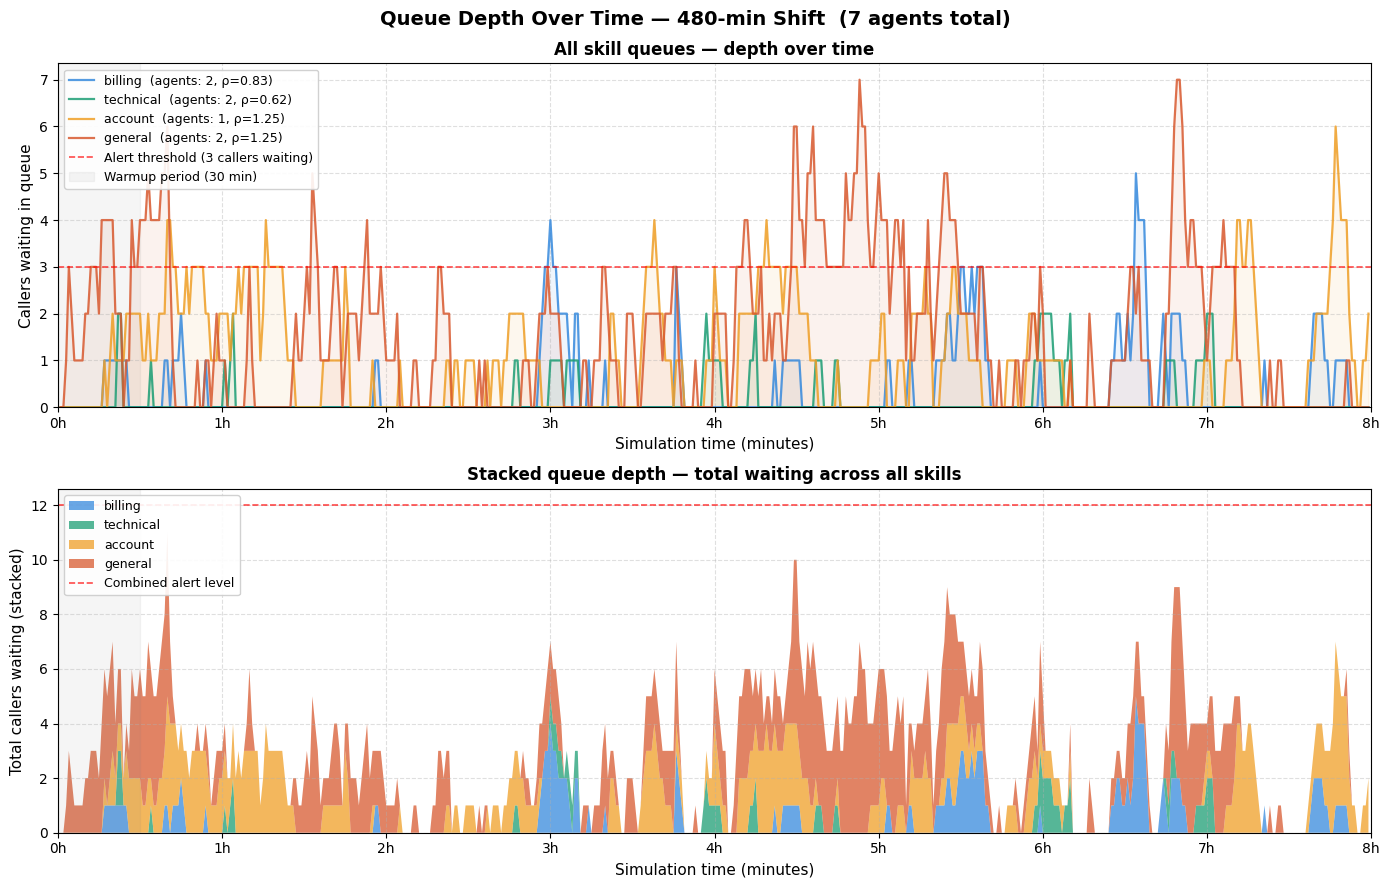

In [20]:
plot_queue_depth(config, results)
#chart 1 show each queue seprately
#chart 2 is the load on the system 3*4=12

---
## Cell 18 — Queue Depth Heatmap

Darker colour = more callers waiting. Instantly shows which skills are the bottleneck.

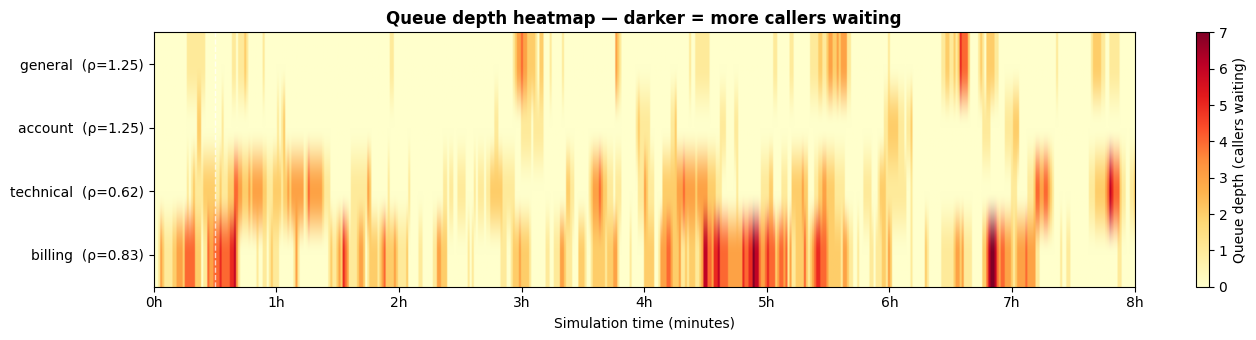

In [21]:
plot_queue_depth_heatmap(config, results)

---
## Cell 19 — KPI Histogram Dashboard

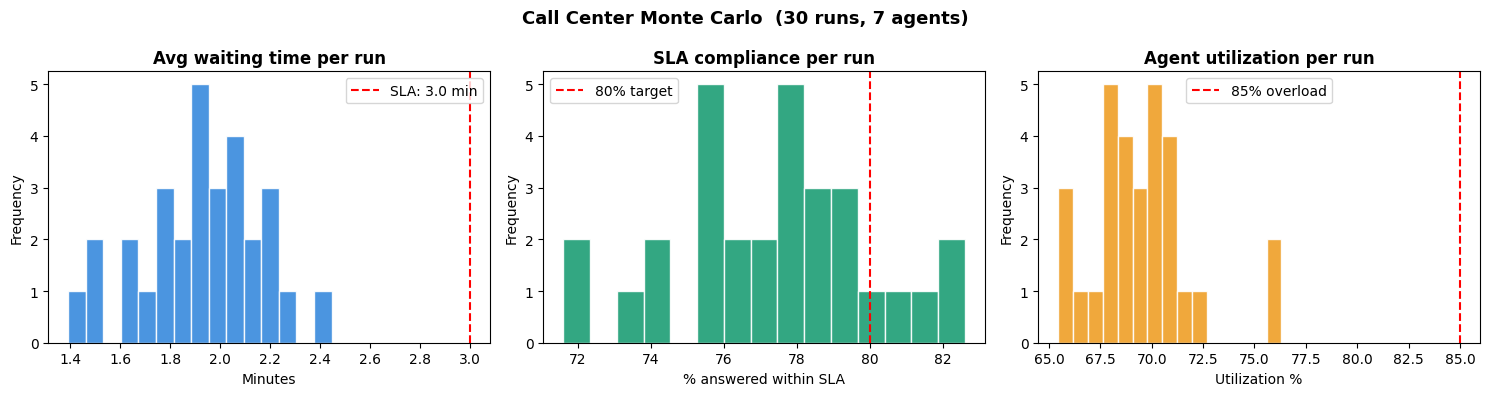

In [22]:
plot_results(config, results)

---
##  Staffing Optimizer :Running optimization with the current original config->Demonstrate queue problem

Find the minimum agents needed to clear the queue and meet the SLA target.

In [23]:
# account is the worst bottleneck (1 agent, ρ=1.25) — sweep it first
find_optimal_staffing(config, skill='account', max_agents=7)


── Staffing optimizer for 'account' (SLA: ≤3.0 min) ──
    Agents       ρ    Avg wait     SLA %    Util %   Abandon %
  ------------------------------------------------------------
Running 15 Monte Carlo replications... 10 done.
         1    1.25       1.89m     77.3%     69.8%       24.7%
Running 15 Monte Carlo replications... 10 done.
         2    0.62       1.47m     82.0%     65.1%       19.5%SLA met 
Running 15 Monte Carlo replications... 10 done.
         3    0.42       1.31m     84.1%     58.7%       18.2%SLA met 
Running 15 Monte Carlo replications... 10 done.
         4    0.31       1.27m     84.6%     53.0%       17.9%SLA met 
Running 15 Monte Carlo replications... 10 done.
         5    0.25       1.26m     84.7%     48.3%       17.8%SLA met 
  (stopping — system underloaded at 5 agents)


In [24]:
# general has highest volume
find_optimal_staffing(config, skill='general', max_agents=6)


── Staffing optimizer for 'general' (SLA: ≤3.0 min) ──
    Agents       ρ    Avg wait     SLA %    Util %   Abandon %
  ------------------------------------------------------------
Running 15 Monte Carlo replications... 10 done.
         1    2.50       2.48m     72.4%     68.8%       35.8%
Running 15 Monte Carlo replications... 10 done.
         2    1.25       1.89m     77.3%     69.8%       24.7%
Running 15 Monte Carlo replications... 10 done.
         3    0.83       1.39m     83.4%     66.7%       18.1%SLA met 
Running 15 Monte Carlo replications... 10 done.
         4    0.62       1.10m     87.1%     61.8%       14.8%SLA met 
Running 15 Monte Carlo replications... 10 done.
         5    0.50       0.97m     88.6%     56.4%       13.4%SLA met 
Running 15 Monte Carlo replications... 10 done.
         6    0.42       0.93m     89.1%     51.6%       12.9%SLA met 


---
## What-if Scenario Comparison

Compare current understaffed scenario vs a recommended staffing level.

In [25]:
# Scenario A: current (understaffed — shows the queue problem)
print('SCENARIO A — Current staffing (shows queuing problem)')
config.print_load_summary()
results_a = run_monte_carlo(config)
print_results(config, results_a)

# Scenario B: fix the two overloaded skills
config_b = copy.deepcopy(config)
config_b.agents_per_skill['account'] = 2   # fix account bottleneck
config_b.agents_per_skill['general'] = 3   # fix general bottleneck

print('\nSCENARIO B — Recommended staffing (+2 agents)')
config_b.print_load_summary()
results_b = run_monte_carlo(config_b)
print_results(config_b, results_b)

# Side-by-side
print('\n── Side-by-side comparison ──────────────────────────')
print(f"  {'Metric':<28}  {'Current':>12}  {'Recommended':>12}")
print('  ' + '-'*58)
for label, key, fmt in [
    ('Avg wait (min)',     'wait',    '{:.2f}'),
    ('SLA compliance (%)', 'sla',     '{:.1f}'),
    ('Agent utilization (%)','util',  '{:.1f}'),
    ('Abandon rate (%)',   'abandon', '{:.1f}'),
]:
    va = fmt.format(results_a[key][0])
    vb = fmt.format(results_b[key][0])
    print(f'  {label:<28}  {va:>12}  {vb:>12}')

cost_diff = config_b.hourly_cost - config.hourly_cost
print(f"  {'Extra cost / hour':<28}  {'':>12}  +${cost_diff:.0f}")
print()

# Queue depth comparison
print('── Queue depth comparison ──')
print('Scenario A (current):')
for skill, records in results_a['queue_depth_sample'].items():
    if records:
        peak = max(d for t, d in records)
        avg  = np.mean([d for t, d in records])
        print(f'  {skill:<12}  peak queue = {peak}  avg = {avg:.1f}')
print('Scenario B (recommended):')
for skill, records in results_b['queue_depth_sample'].items():
    if records:
        peak = max(d for t, d in records)
        avg  = np.mean([d for t, d in records])
        print(f'  {skill:<12}  peak queue = {peak}  avg = {avg:.1f}')

SCENARIO A — Current staffing (shows queuing problem)

── Traffic Intensity Check ──────────────────────────
  Skill            IAT   Agents       ρ  Status
  ----------------------------------------------------
  billing         3.0m        2    0.83  OK
  technical       4.0m        2    0.62  OK
  account         4.0m        1    1.25  OVERLOADED 
  general         2.0m        2    1.25  OVERLOADED 

  Total agent seats : 7
  Hourly cost       : $175
─────────────────────────────────────────────────────

Running 30 Monte Carlo replications... 10 20 30 done.

  Call Center Simulation — Results Summary
  Replications  : 30
  Shift length  : 480 min  (warmup discarded: 30 min)
  Agent seats   : 7  {'billing': 2, 'technical': 2, 'account': 1, 'general': 2}
  SLA target    : ≤3.0 min
  Hourly cost   : $175
----------------------------------------------------------
  KPI                                Mean  95% CI
----------------------------------------------------------
  Avg wait time 